# Website User Performance Analysis

In [2]:
# Defining Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
#Reading data 

df=pd.read_csv("website_users.csv")

In [4]:
df.head(5)

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In this the header is not defined, so we learn how to assign the first row as header

In [6]:
#First we extract the first row and store it in a variable
#df.columns=df.iloc[0]

In [7]:
#df.columns

Index(['Session primary channel group (Default channel group)',
       'Date + hour (YYYYMMDDHH)', 'Users', 'Sessions', 'Engaged sessions',
       'Average engagement time per session', 'Engaged sessions per user',
       'Events per session', 'Engagement rate', 'Event count'],
      dtype='object', name=0)

In [5]:
df.columns=df.iloc[0]
df=df.drop(index=0).reset_index(drop=True)
df.columns=["Session Channel Group","Date Time","Users", "Sessions","Engaged sessions"	,"Average Engagement Time","Engaged Sessions Per User","Events Per Session","Engagement Rate","Event Count"]

In [6]:
df.head(5)

,Session Channel Group,Date Time,Users,Sessions,Engaged sessions,Average Engagement Time,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Session Channel Group      3182 non-null   object
 1   Date Time                  3182 non-null   object
 2   Users                      3182 non-null   object
 3   Sessions                   3182 non-null   object
 4   Engaged sessions           3182 non-null   object
 5   Average Engagement Time    3182 non-null   object
 6   Engaged Sessions Per User  3182 non-null   object
 7   Events Per Session         3182 non-null   object
 8   Engagement Rate            3182 non-null   object
 9   Event Count                3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [8]:
df.describe()

,Session Channel Group,Date Time,Users,Sessions,Engaged sessions,Average Engagement Time,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count
count,3182,3182,3182,3182,3182,3182,3182,3182,3182,3182
unique,7,672,147,180,103,2823,808,2025,986,678
top,Direct,2024050121,1,1,0,0,0,1,0,1
freq,672,6,335,340,393,170,393,133,393,115


In [9]:
#First we convert the date time column to proper datatype from object to datetime
df['Date Time']=pd.to_datetime(df['Date Time'], format='%Y%m%d%H',errors='coerce')

In [10]:
df.head()

,Session Channel Group,Date Time,Users,Sessions,Engaged sessions,Average Engagement Time,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Session Channel Group      3182 non-null   object        
 1   Date Time                  3182 non-null   datetime64[ns]
 2   Users                      3182 non-null   object        
 3   Sessions                   3182 non-null   object        
 4   Engaged sessions           3182 non-null   object        
 5   Average Engagement Time    3182 non-null   object        
 6   Engaged Sessions Per User  3182 non-null   object        
 7   Events Per Session         3182 non-null   object        
 8   Engagement Rate            3182 non-null   object        
 9   Event Count                3182 non-null   object        
dtypes: datetime64[ns](1), object(9)
memory usage: 248.7+ KB


In [12]:
#Converting the other columns to numeric and extracting Hour from Date Time
numeric_cols=df.columns.drop(["Session Channel Group","Date Time"])
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric,errors='coerce')
df["Hour"]=df["Date Time"].dt.hour

In [13]:
df.head(5)

,Session Channel Group,Date Time,Users,Sessions,Engaged sessions,Average Engagement Time,Engaged Sessions Per User,Events Per Session,Engagement Rate,Event Count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Session Channel Group      3182 non-null   object        
 1   Date Time                  3182 non-null   datetime64[ns]
 2   Users                      3182 non-null   int64         
 3   Sessions                   3182 non-null   int64         
 4   Engaged sessions           3182 non-null   int64         
 5   Average Engagement Time    3182 non-null   float64       
 6   Engaged Sessions Per User  3182 non-null   float64       
 7   Events Per Session         3182 non-null   float64       
 8   Engagement Rate            3182 non-null   float64       
 9   Event Count                3182 non-null   int64         
 10  Hour                       3182 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(4), object(1)
memor

# 1. Sessions and Users over Time

In [15]:
sns.set(style="whitegrid")

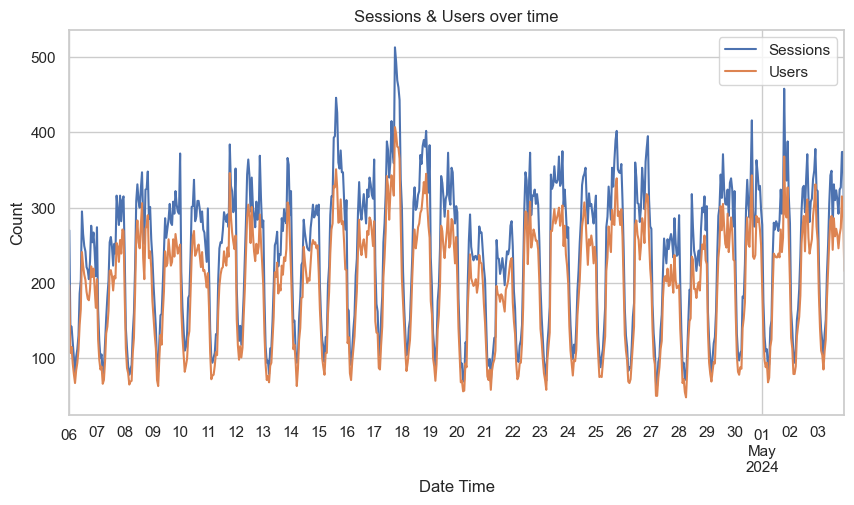

In [16]:
plt.figure(figsize=(10,5))
df.groupby("Date Time")[["Sessions", "Users"]].sum().plot(ax=plt.gca())
plt.title("Sessions & Users over time")
plt.xlabel("Date Time")
plt.ylabel("Count")
plt.show()

#Insights: We have observed the spikes in sessions and users engagement was high during the mid afternoon period(i.e from 4 to 7 PM)

# 2. Total Users by Channel

C:\Users\SAGAR\AppData\Local\Temp\ipykernel_16720\1898700367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Session Channel Group",y="Users",estimator=np.sum,palette="viridis")


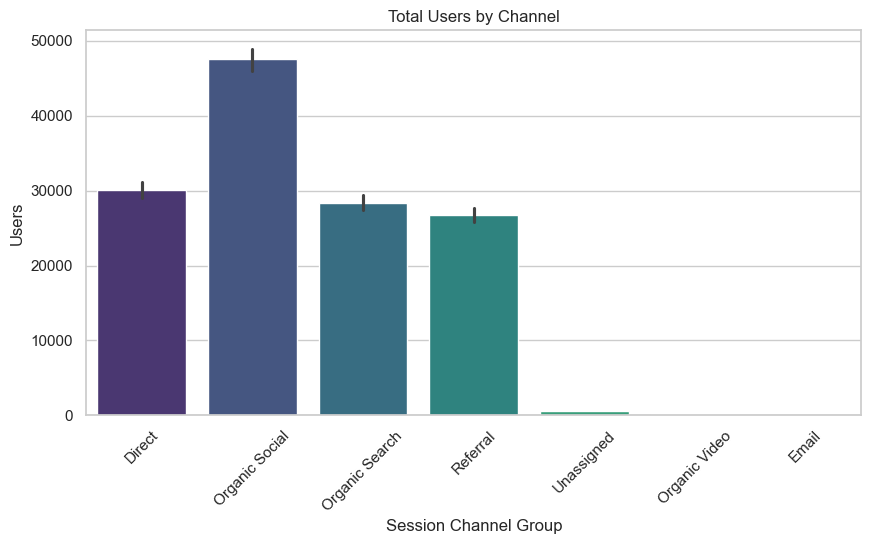

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Session Channel Group",y="Users",estimator=np.sum,palette="viridis")
plt.title("Total Users by Channel")
plt.xticks(rotation=45)
plt.show()

# 3. Average Engagement Time by Channel

C:\Users\SAGAR\AppData\Local\Temp\ipykernel_16720\1582605913.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="Session Channel Group",y="Average Engagement Time",estimator=np.average,palette="magma")


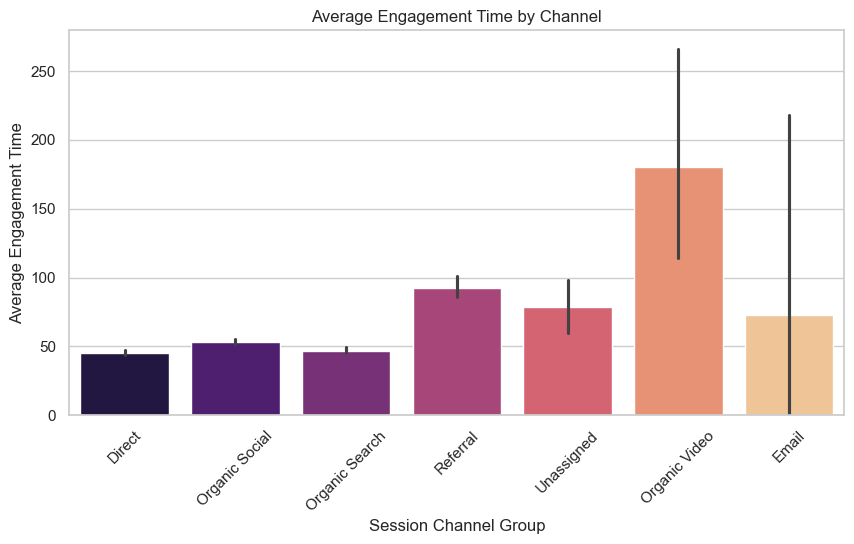

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Session Channel Group",y="Average Engagement Time",estimator=np.average,palette="magma")
plt.title("Average Engagement Time by Channel")
plt.xticks(rotation=45)
plt.show()

# 4. Engagement Rate Distribution by Channel

C:\Users\SAGAR\AppData\Local\Temp\ipykernel_16720\90792596.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Session Channel Group",y="Engagement Rate",palette="coolwarm")


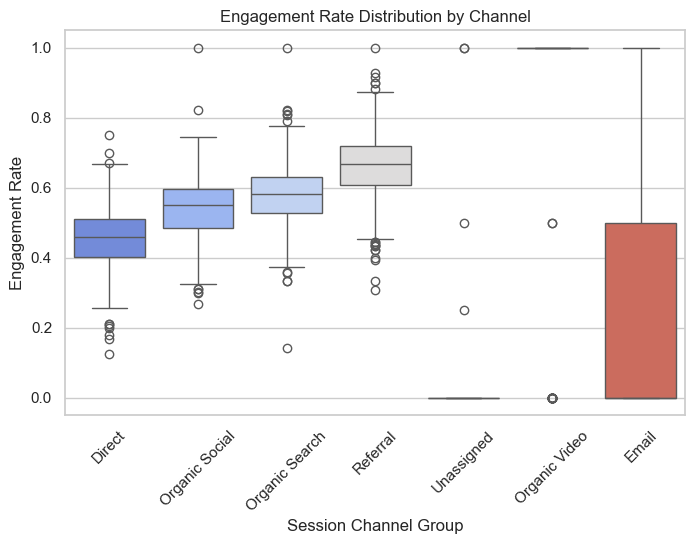

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Session Channel Group",y="Engagement Rate",palette="coolwarm")
plt.title("Engagement Rate Distribution by Channel")
plt.xticks(rotation=45)
plt.show()

# 5. Engaged vs Non-engaged Sessions

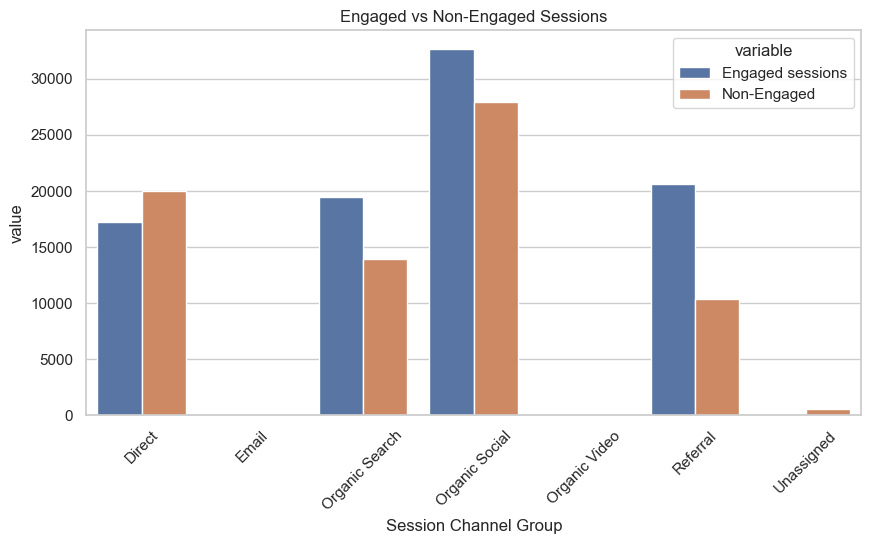

In [20]:
session_df=df.groupby("Session Channel Group")[["Sessions", "Engaged sessions"]].sum().reset_index()
session_df["Non-Engaged"]=session_df["Sessions"] - session_df["Engaged sessions"]
session_df_melted=session_df.melt(id_vars="Session Channel Group", value_vars=["Engaged sessions","Non-Engaged"])

plt.figure(figsize=(10,5))
sns.barplot(data=session_df_melted,x="Session Channel Group",y="value",hue="variable")
plt.title("Engaged vs Non-Engaged Sessions")
plt.xticks(rotation=45)
plt.show()

# 6. Traffic by Hour and Channel

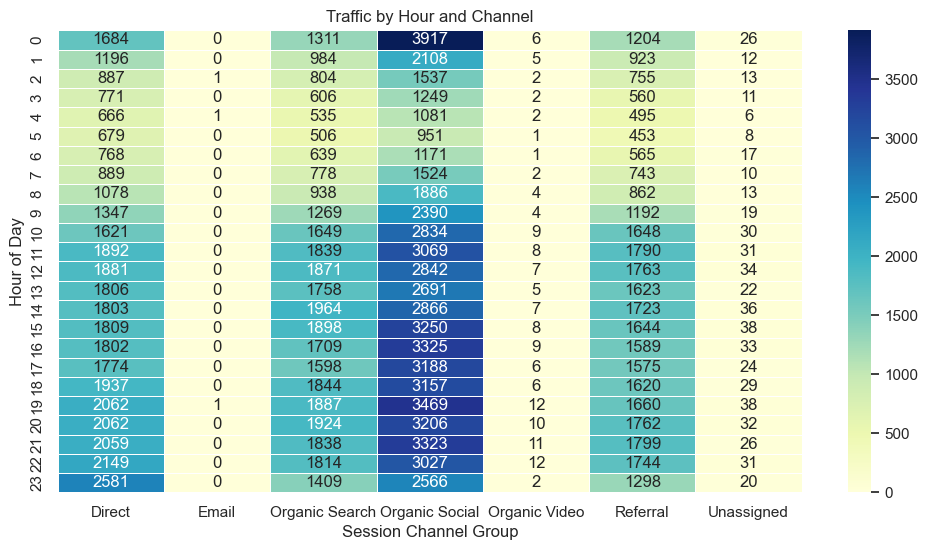

In [22]:
heatmap_data=df.groupby(["Hour","Session Channel Group"])["Sessions"].sum().unstack().fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap="YlGnBu",linewidths=0.5,annot=True,fmt='.0f')
plt.title('Traffic by Hour and Channel')
plt.xlabel('Session Channel Group')
plt.ylabel('Hour of Day')
plt.show()

# 7. Engagement Rate vs Sessions Over Time

NameError: name 'mdates' is not defined

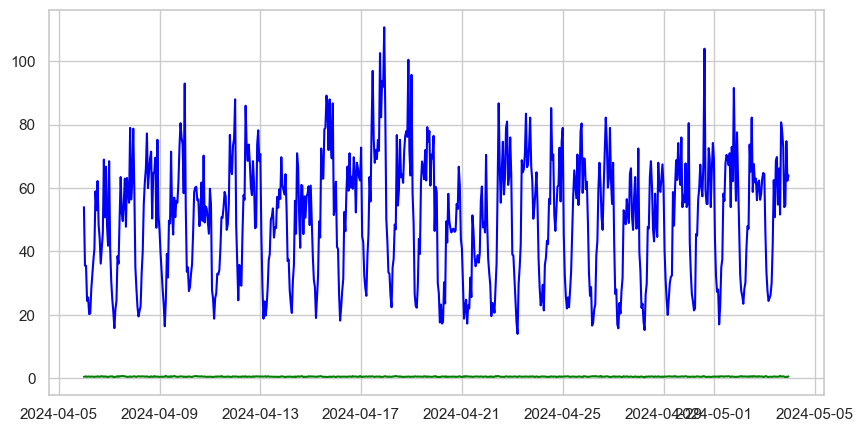

In [40]:
df_plot=df.groupby("Date Time")[["Engagement Rate", "Sessions"]].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(df_plot["Date Time"], df_plot["Engagement Rate"], label="Engagement Rate", color="green")
plt.plot(df_plot["Date Time"], df_plot["Sessions"], label="Sessions", color="blue")

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 

plt.plot("Engagement Rate vs Sessions Over Time")
plt.xlabel("Date Time")
plt.legend()
plt.grid(True)
plt.show()